# Load the titanic dataset and create csv file

In [38]:

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset from seaborn.
df = sns.load_dataset("titanic")

# Save an offline copy immediately.
DATA_DIR = Path.cwd() / "analytics"

# If the notebook is running inside the analytics
# folder, use the current directory instead.
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd()

DATA_DIR.mkdir(exist_ok=True)
df.to_csv(DATA_DIR / "titanic.csv", index=False)

print("Dataset saved successfully!")
print("Shape:", df.shape)
df.head()

Dataset saved successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Inspect the dataset

In [39]:

print("Dataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)

print("\nMissing values (%):")
missing_pct = (
    df.isna().mean() * 100
).sort_values(ascending=False)

display(missing_pct.to_frame("missing_percentage"))

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values (%):


,missing_percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
survived,0.000000
pclass,0.000000
sex,0.000000
sibsp,0.000000
parch,0.000000
fare,0.000000


# EDA working copy without changing the original CSV and doing clean up

In [40]:

# Keep the original dataset unchanged.
eda = df.copy()

# Remove deck because 77% of its values are missing.
# embark_town duplicates information in embarked.
eda = eda.drop(columns=["deck", "embark_town"])

# Only two passengers have missing embarked values.
# Drop those rows for exploratory analysis.
eda = eda.dropna(subset=["embarked"]).copy()

print("EDA dataset shape:", eda.shape)
print("\nRemaining missing values:")
print(eda.isna().sum()[eda.isna().sum() > 0])

EDA dataset shape: (889, 13)

Remaining missing values:
age    177
dtype: int64


# Create age and fare histograms and boxplots

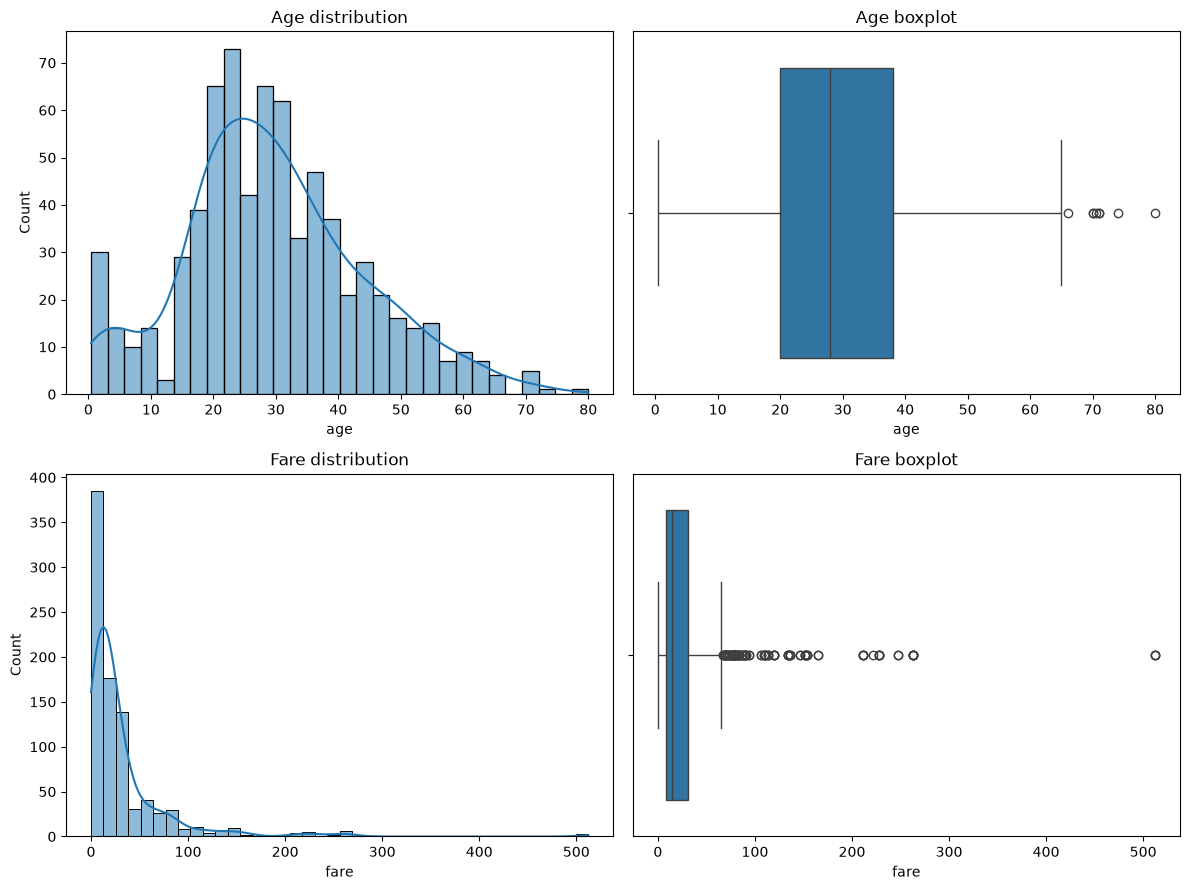

In [41]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(
    data=eda, x="age", bins=30, kde=True, ax=axes[0, 0]
)
axes[0, 0].set_title("Age distribution")

sns.boxplot(
    data=eda, x="age", ax=axes[0, 1]
)
axes[0, 1].set_title("Age boxplot")

sns.histplot(
    data=eda, x="fare", bins=40, kde=True, ax=axes[1, 0]
)
axes[1, 0].set_title("Fare distribution")

sns.boxplot(
    data=eda, x="fare", ax=axes[1, 1]
)
axes[1, 1].set_title("Fare boxplot")

plt.tight_layout()
plt.show()

# Histogram and box-plot interpretations

# 1. Age distribution — Histogram

The age distribution is concentrated among young and middle-aged adults, with relatively fewer passengers at older ages. The average recorded age is approximately 29.7 years, and the median is 28 years. This suggests that the age distribution is moderately right-skewed, although the mean and median are fairly close. Missing ages are excluded from this visualization rather than imputed.

# 2. Age distribution — Boxplot

The age boxplot shows the median and the spread of passenger ages, along with a small number of potential outliers. Using the 1.5 × IQR rule, eight age observations were identified as outliers. These are unusually high or low ages relative to the central distribution, but they are not necessarily incorrect. Therefore, they should not be removed without further investigation.

# 3. Fare distribution — Histogram

The fare distribution is highly right-skewed, with most passengers paying relatively low fares and a smaller number paying much higher fares. The mean fare is £32.10, considerably higher than the median of £14.45 and mode of £8.05. The skewness value of 4.80 confirms a strong positive skew, indicating that a small number of expensive tickets pull the average upward.

# 4. Fare distribution — Boxplot

The fare boxplot reveals numerous observations above the upper IQR boundary. A total of 114 fare observations were identified as potential outliers using the 1.5 × IQR rule. These observations help explain the strong positive skew observed in the histogram. Since higher fares may represent legitimate first-class tickets, these values should not automatically be treated as data-entry errors or removed.

# Calculate IQR outliers and fare statistics

In [42]:

def iqr_outlier_summary(series):
    values = series.dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (values < lower) | (values > upper)

    return {
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower bound": round(lower, 2),
        "Upper bound": round(upper, 2),
        "Outlier count": int(outliers.sum())
    }


print("Age outliers:")
print(iqr_outlier_summary(eda["age"]))

print("\nFare outliers:")
print(iqr_outlier_summary(eda["fare"]))

print("\nFare statistics:")
print(f"Mean: {eda['fare'].mean():.2f}")
print(f"Median: {eda['fare'].median():.2f}")
print(f"Mode: {eda['fare'].mode().iloc[0]:.2f}")
print(f"Skewness: {eda['fare'].skew():.2f}")

print("\nAge statistics:")
print(f"Mean: {eda['age'].mean():.2f}")
print(f"Median: {eda['age'].median():.2f}")
print(f"Mode: {eda['age'].mode().iloc[0]:.2f}")
print(f"Skewness: {eda['age'].skew():.2f}")

Age outliers:
{'Q1': np.float64(20.0), 'Q3': np.float64(38.0), 'IQR': np.float64(18.0), 'Lower bound': np.float64(-7.0), 'Upper bound': np.float64(65.0), 'Outlier count': 8}

Fare outliers:
{'Q1': np.float64(7.9), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1), 'Lower bound': np.float64(-26.76), 'Upper bound': np.float64(65.66), 'Outlier count': 114}

Fare statistics:
Mean: 32.10
Median: 14.45
Mode: 8.05
Skewness: 4.80

Age statistics:
Mean: 29.64
Median: 28.00
Mode: 24.00
Skewness: 0.39


# Calculate survival rates

In [43]:

# Overall survival rate
overall = eda["survived"].mean() * 100
print(f"Overall survival rate: {overall:.2f}%")

# Survival rate by sex
print("\nSurvival rate by sex:")
sex_survival = (
    eda.groupby("sex", observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
)
display(sex_survival)

# Survival rate by passenger class
print("\nSurvival rate by passenger class:")
class_survival = (
    eda.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)
display(class_survival)

# Survival rate by sex and passenger class
print("\nSurvival rate by sex and class:")
sex_class_survival = (
    eda.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)
display(sex_class_survival)

Overall survival rate: 38.25%

Survival rate by sex:


sex
female    74.04
male      18.89
Name: survived, dtype: float64


Survival rate by passenger class:


pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64


Survival rate by sex and class:


pclass,1,2,3
sex,,,
female,96.74,92.11,50.00
male,36.89,15.74,13.54


# Survival rate interpretations

# 1. Overall survival rate

The overall survival rate in the EDA dataset is 38.25%, indicating that fewer than four in ten passengers survived. This analysis uses 889 passengers after excluding the two records with missing embarkation information. The survival rate provides a useful baseline for comparing different passenger groups.

# 2. Survival rate by sex
Female passengers had a survival rate of 74.04%, compared with 18.89% for male passengers. This difference of 55.15 percentage points indicates a strong association between sex and survival in the dataset. However, these descriptive results alone cannot establish that sex independently caused the difference, because other factors, including passenger class and age, may also be relevant.

# 3. Survival rate by passenger class
Survival rates decreased across passenger classes, from 62.62% in first class to 47.28% in second class and 24.24% in third class. First-class passengers had an observed survival rate approximately 2.6 times that of third-class passengers. This suggests an association between passenger class and survival, although the analysis does not establish which underlying circumstances explain the difference.

# 4. Survival rate by sex and passenger class
When sex and passenger class are considered together, female passengers had higher observed survival rates than male passengers in every class. First-class females had the highest rate at 96.74%, followed by second-class females at 92.11%, while third-class females had a substantially lower rate of 50.00%. Among male passengers, survival was 36.89% in first class, 15.74% in second class and 13.54% in third class. These findings show that both sex and passenger class are associated with survival, and that examining the two variables together reveals differences that separate group averages cannot fully describe.

# using boolean masking

In [44]:

# Example: female passengers
female = eda[eda["sex"] == "female"]

# Example: third-class passengers
third_class = eda[eda["pclass"] == 3]

# Example: female third-class passengers
female_third = eda[
    (eda["sex"] == "female")
    & (eda["pclass"] == 3)
]

print(
    "Female survival rate:",
    round(female["survived"].mean() * 100, 2),
    "%"
)

print(
    "Third-class survival rate:",
    round(third_class["survived"].mean() * 100, 2),
    "%"
)

print(
    "Female third-class survival rate:",
    round(female_third["survived"].mean() * 100, 2),
    "%"
)

Female survival rate: 74.04 %
Third-class survival rate: 24.24 %
Female third-class survival rate: 50.0 %


# Visualize survival by sex and class

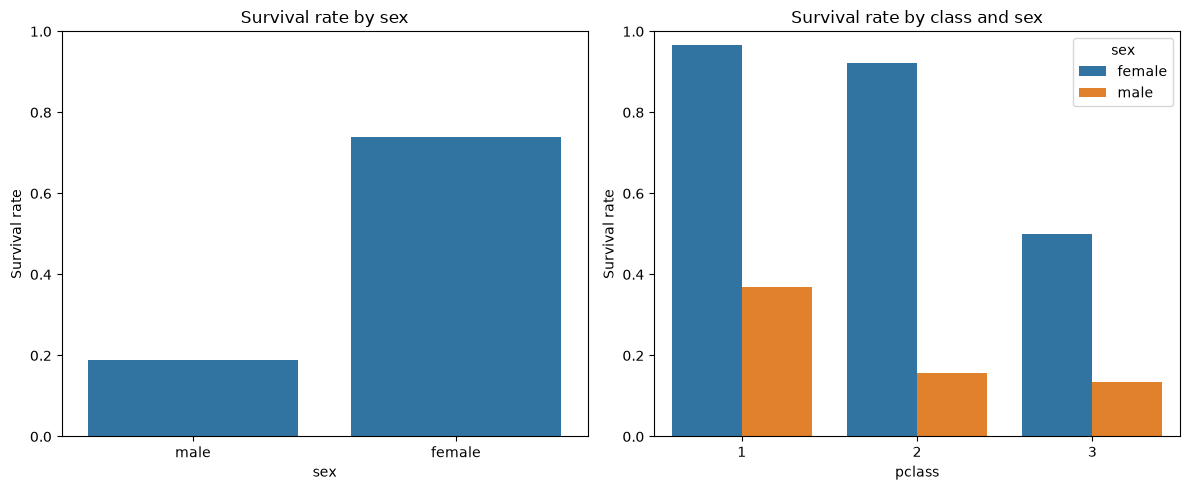

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=eda,
    x="sex",
    y="survived",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Survival rate by sex")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1)

sns.barplot(
    data=eda,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Survival rate by class and sex")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Create the correlation heatmap

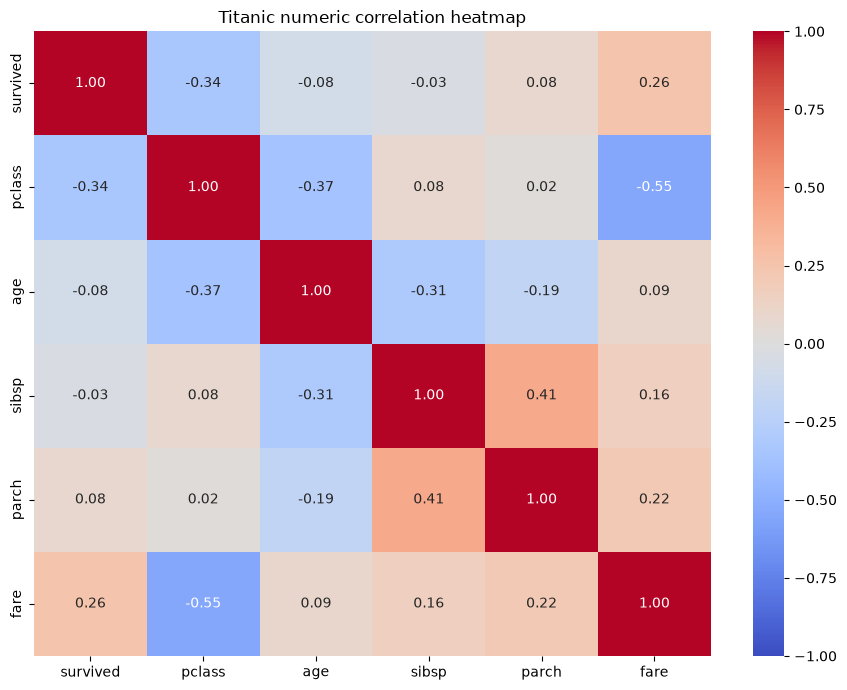

In [46]:

numeric_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = eda[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Titanic numeric correlation heatmap")
plt.tight_layout()
plt.show()

# Identify the two strongest correlations
We must exclude the diagonal (where every variable correlates perfectly with itself) and avoid counting each pair twice.

In [47]:

import numpy as np

# Keep only the upper triangle, excluding the diagonal.
upper_triangle = np.triu(
    np.ones(corr_matrix.shape, dtype=bool),
    k=1
)

correlation_pairs = (
    corr_matrix.where(upper_triangle)
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

correlation_pairs["Absolute correlation"] = (
    correlation_pairs["Correlation"].abs()
)

top_two = (
    correlation_pairs
    .sort_values("Absolute correlation", ascending=False)
    .head(2)
)

display(top_two)

,Variable 1,Variable 2,Correlation,Absolute correlation
11,pclass,fare,-0.548193,0.548193
22,sibsp,parch,0.414542,0.414542


# 5. Correlation heatmap

Your two strongest correlations, ranked by absolute magnitude, are:

Passenger class and fare:

Passenger class and fare have the strongest absolute correlation among the six numeric variables examined, with a Pearson coefficient of −0.548. Since passenger class is coded numerically from 1 (first class) to 3 (third class), the negative correlation indicates that lower class numbers tend to be associated with higher fares. This is consistent with first-class passengers generally paying more expensive fares. The relationship is moderate rather than perfect because fares also vary within each class.

Siblings/spouses and parents/children:

The second-strongest correlation is between sibsp and parch, with a coefficient of +0.415. This moderate positive relationship indicates that passengers traveling with more siblings or spouses also tended to travel with more parents or children. Both variables describe family members aboard the Titanic, so their positive association is plausible. However, the relationship is not perfect because passengers could travel with one type of family member without the other.

Important distinction:

These are the two strongest correlations across all six selected numeric variables, not necessarily the two strongest correlations with survival. The correlation heatmap describes linear associations and does not demonstrate causation.

# Age distribution by survival

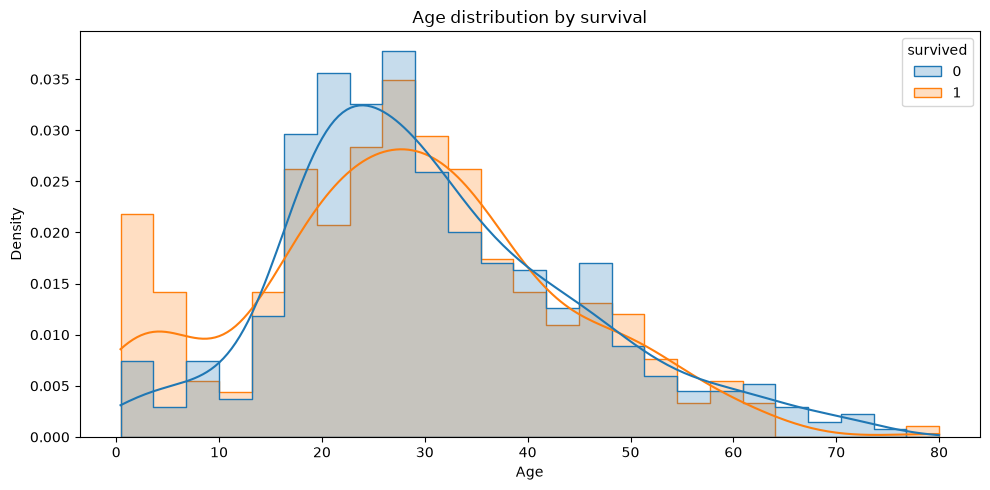

In [48]:

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda,
    x="age",
    hue="survived",
    bins=25,
    kde=True,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Age distribution by survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Age distribution by survival

The age distributions of survivors and non-survivors overlap substantially, with most passengers concentrated between approximately 15 and 40 years old. The survivor distribution shows a noticeable concentration among young children, particularly those below five years old. However, the considerable overlap between the two distributions suggests that age alone is not sufficient to distinguish survivors from non-survivors.

# Fare by passenger class and survival

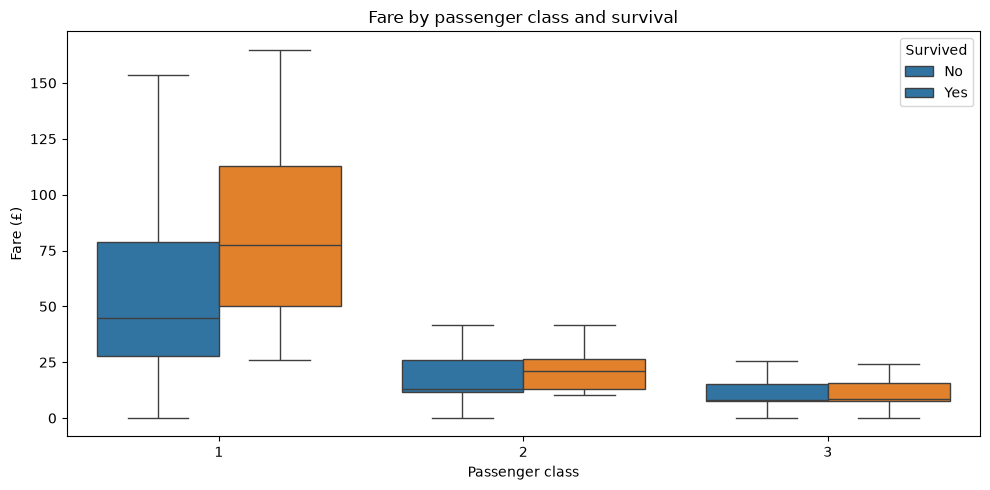

In [49]:

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda,
    x="pclass",
    y="fare",
    hue="survived",
    showfliers=False
)

plt.title("Fare by passenger class and survival")
plt.xlabel("Passenger class")
plt.ylabel("Fare (£)")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)
plt.tight_layout()
plt.show()

# Fare by passenger class and survival

First-class passengers generally paid much higher fares than second- and third-class passengers. Within first class, survivors had a higher median fare (approximately £77) than non-survivors (approximately £45). The difference is smaller in second class, while the fare distributions of survivors and non-survivors overlap considerably in third class. These results suggest that the relationship between fare and survival varies across passenger classes.

# Survival by age group and sex

,age_group,sex,survival_rate,passengers
0,Child,female,0.593750,32
1,Child,male,0.567568,37
2,Teen,female,0.750000,36
3,Teen,male,0.088235,34
4,Young adult,female,0.783333,120
5,Young adult,male,0.180672,238
6,Middle-aged,female,0.768116,69
7,Middle-aged,male,0.192000,125
8,Senior,female,1.000000,2
9,Senior,male,0.105263,19


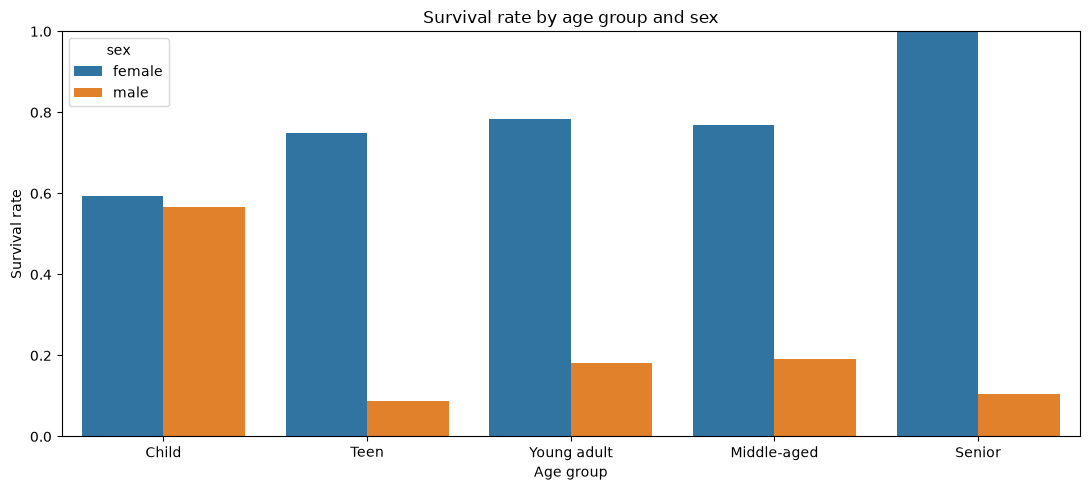

In [50]:

eda["age_group"] = pd.cut(
    eda["age"],
    bins=[0, 12, 18, 35, 60, float("inf")],
    labels=[
        "Child",
        "Teen",
        "Young adult",
        "Middle-aged",
        "Senior"
    ],
    include_lowest=True
)

age_sex_summary = (
    eda.groupby(
        ["age_group", "sex"],
        observed=True
    )
    .agg(
        survival_rate=("survived", "mean"),
        passengers=("survived", "size")
    )
    .reset_index()
)

display(age_sex_summary)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=age_sex_summary,
    x="age_group",
    y="survival_rate",
    hue="sex",
    errorbar=None
)

plt.title("Survival rate by age group and sex")
plt.xlabel("Age group")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Survival rate by age group and sex

Female passengers had higher observed survival rates across all age groups, with the smallest difference occurring among children (59.38% for girls versus 56.76% for boys). The difference was particularly pronounced among teenagers, where 27 of 36 females survived compared with 3 of 34 males. Although senior females show 100% survival, this represents only two passengers and should not be generalized.

# Passenger counts by age group and sex

In [54]:

# Passenger counts by age group and sex
age_group_counts = (
    eda.groupby(["age_group", "sex"], observed=True)
    .agg(
        passengers=("survived", "size"),
        survivors=("survived", "sum"),
        survival_rate=("survived", "mean")
    )
    .reset_index()
)

age_group_counts["survival_rate"] = (
    age_group_counts["survival_rate"] * 100
).round(2)

display(age_group_counts)

,age_group,sex,passengers,survivors,survival_rate
0,Child,female,32,19,59.38
1,Child,male,37,21,56.76
2,Teen,female,36,27,75.00
3,Teen,male,34,3,8.82
4,Young adult,female,120,94,78.33
5,Young adult,male,238,43,18.07
6,Middle-aged,female,69,53,76.81
7,Middle-aged,male,125,24,19.20
8,Senior,female,2,2,100.00
9,Senior,male,19,2,10.53


# Survival by embarkation port and passenger class

,embarked,pclass,survived
0,C,1,0.694118
1,C,2,0.529412
2,C,3,0.378788
3,Q,1,0.500000
4,Q,2,0.666667
5,Q,3,0.375000
6,S,1,0.582677
7,S,2,0.463415
8,S,3,0.189802


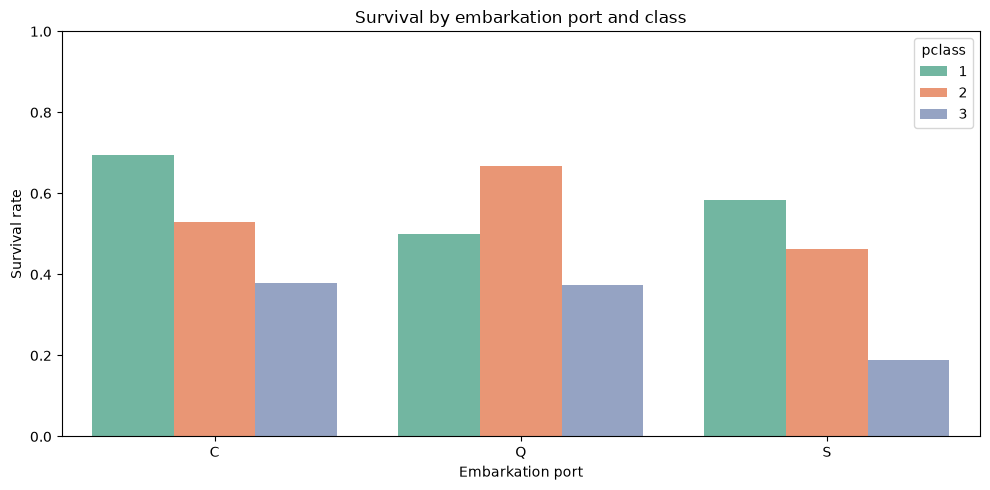

In [56]:

port_class_summary = (
    eda.groupby(
        ["embarked", "pclass"]
    )["survived"]
    .mean()
    .reset_index()
)

display(port_class_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=port_class_summary,
    x="embarked",
    y="survived",
    hue="pclass",
    palette="Set2",
    errorbar=None
)

plt.title("Survival by embarkation port and class")
plt.xlabel("Embarkation port")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Survival by embarkation port and passenger class

Survival rates generally decreased from first to third class among passengers embarking at Cherbourg and Southampton. At Cherbourg, 59 of 85 first-class passengers survived (69.41%), while at Southampton, only 67 of 353 third-class passengers survived (18.98%). Queenstown's second-class survival rate was 66.67%, but this was based on only three passengers. Similarly, Queenstown's first-class survival rate was 50%, representing just one survivor out of two passengers. These small groups should not be used to draw broad conclusions.

# Passenger counts by embarkation port and class

In [53]:

port_class_counts = (
    eda.groupby(["embarked", "pclass"], observed=True)
    .agg(
        passengers=("survived", "size"),
        survivors=("survived", "sum"),
        survival_rate=("survived", "mean")
    )
    .reset_index()
)

port_class_counts["survival_rate"] = (
    port_class_counts["survival_rate"] * 100
).round(2)

display(port_class_counts)

,embarked,pclass,passengers,survivors,survival_rate
0,C,1,85,59,69.41
1,C,2,17,9,52.94
2,C,3,66,25,37.88
3,Q,1,2,1,50.00
4,Q,2,3,2,66.67
5,Q,3,72,27,37.50
6,S,1,127,74,58.27
7,S,2,164,76,46.34
8,S,3,353,67,18.98


# Z-score standardization

In [52]:

from sklearn.preprocessing import StandardScaler

eda_scaled = eda[["age", "fare"]].copy()

scaler = StandardScaler()

eda_scaled[["age_z", "fare_z"]] = scaler.fit_transform(
    eda_scaled[["age", "fare"]]
)

print("Standardized feature statistics:")

display(
    eda_scaled[["age_z", "fare_z"]]
    .agg(["mean", "std"])
    .round(4)
)

Standardized feature statistics:


,age_z,fare_z
mean,0.0000,0.0000
std,1.0007,1.0006
